## 5. Gene Embedding Analysis Tutorial

Uses the **90/10** PerturbGen extract from notebook 4
(`masking_split/embeddings_90_10_atlas`, 19 Aug).
Do not re-run the dump unless that h5ad is missing.


In this notebook, we explore gene embeddings as a framework for de novo gene program discovery. Genes grouped into the same program may represent coordinated biological functions and can serve as candidate targets for downstream perturbation studies.

We use the AnnData from Notebook 4:
- **cell embeddings** in `adata.obsm['cls_embeddings']`
- **gene embeddings** per LPS timepoint in `adata.varm` (`90m_LPS`, `6h_LPS`, `10h_LPS`)

This is the **90/10 checkpoint** extract: every unique `cell_pairing_index` in the MaskGIT dump (`--split False`), gene times in `varm`. No train/val filter here.


Load the libraries

In [7]:
import scanpy as sc
import matplotlib as mpl
import numpy as np
import pandas as pd
import anndata as ad
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

### Config — paths for this analysis

`EMB_H5AD` = 90/10 cell + gene embeddings (notebook 4 dump).  
`FULL_H5AD` = entire LPS paired expression object (all times; UMAP / violins).  
`GENE_NAME_ID_DICT` = Geneformer symbol↔Ensembl map (for readable gene names).


In [2]:
from pathlib import Path
import pickle
import scanpy as sc

WORKSPACE = Path("/home/stuke1/perturbgen")
SOD2 = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")

# 90/10 MaskGIT extract from notebook 4 (do not use the 16 Aug paper atlas).
EMB_DIR = SOD2 / "T_perturb" / "res" / "masking_split" / "embeddings_90_10_atlas"
EMB_H5AD = EMB_DIR / "20260819-11:06_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad"

# Gene-program figures live next to this extract.
RESULTS_DIR = EMB_DIR / "gene_program_discovery"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# LPS expression AnnData (for optional expression UMAP / violin plots)
FULL_H5AD = (
    WORKSPACE
    / "T_perturb"
    / "tokenized_data"
    / "LPS_all_tps_2k"
    / "h5ad_pairing_2000_hvg_GF_genes"
    / "LPS_all_tps_2k.h5ad"
)

# Ensembl -> gene symbol (Geneformer)
GENE_NAME_ID_DICT = Path(
    "/mnt/sod2-project/csb4/stuke1/Geneformer/geneformer/gene_name_id_dict.pkl"
)

for p in (EMB_H5AD, FULL_H5AD, GENE_NAME_ID_DICT):
    assert Path(p).is_file(), f"missing: {p}"

print("EMB_DIR:", EMB_DIR)
print("EMB_H5AD:", EMB_H5AD)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIG_DIR:", FIG_DIR)
print("FULL_H5AD:", FULL_H5AD)
if (EMB_DIR / "ckpt_info.txt").is_file():
    print("--- ckpt_info ---")
    print((EMB_DIR / "ckpt_info.txt").read_text())

adata = sc.read(EMB_H5AD)
print(adata)
print("obsm:", list(adata.obsm.keys()), "| varm:", list(adata.varm.keys()))
print("n_embedding_cells (unique pairing):", adata.n_obs)
assert "embeddings_90_10_atlas" in str(EMB_H5AD), EMB_H5AD
assert "embeddings_full_atlas" not in str(EMB_H5AD), "refusing 16 Aug paper atlas"
assert "benchmark_test" not in str(EMB_H5AD), "refusing test-split extract"


EMB_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_90_10_atlas
EMB_H5AD: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_90_10_atlas/20260819-11:06_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad
RESULTS_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_90_10_atlas/gene_program_discovery
FIG_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_90_10_atlas/gene_program_discovery/figures
FULL_H5AD: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_GF_genes/LPS_all_tps_2k.h5ad
--- ckpt_info ---
ckpt=/home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260818_2346_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_256_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
split_path=/home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_90_10.pkl (unused; extract us

AnnData object with n_obs × n_vars = 69531 × 1856
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: '10h_LPS', '6h_LPS', '90m_LPS'
obsm: ['cls_embeddings'] | varm: ['10h_LPS', '6h_LPS', '90m_LPS']
n_embedding_cells (unique pairing): 69531


For each timepoint, the model provides gene embeddings stored in varm, while cell embeddings are available under cls_embeddings.

In [3]:
print(adata)
print("obsm keys:", list(adata.obsm.keys()))
print("varm keys:", list(adata.varm.keys()))

AnnData object with n_obs × n_vars = 69531 × 1856
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: '10h_LPS', '6h_LPS', '90m_LPS'
obsm keys: ['cls_embeddings']
varm keys: ['10h_LPS', '6h_LPS', '90m_LPS']


In [4]:
# Gene embeddings by timepoint
for tp in ["90m_LPS", "6h_LPS", "10h_LPS"]:
    g = adata.varm[tp]
    print(tp, g.shape)                     # (n_genes, d_model)
    print(g[:3, :8])                       # first 3 genes, first 8 dims               # first 3 cells, first 8 dims           # first 3 cells, first 8 dims

90m_LPS (1856, 768)
[[ 0.1823983  -0.28955773 -0.43822986 -1.7701766   0.46895352 -0.44209424
  -0.07132373  0.6855164 ]
 [-0.41035676  1.6612391   0.14451465  0.10146871  0.519492    1.2144722
   1.1606499  -0.20099664]
 [-0.11210806 -0.3402698  -0.16688554 -0.6510402   1.1137966  -0.6846641
  -0.6607984   0.66487384]]
6h_LPS (1856, 768)
[[ 0.0216991  -0.11764984 -0.16537547 -2.1276357  -0.73876894 -0.37191397
   0.26575422  0.5325009 ]
 [-0.5953028   1.6856399  -0.05702832 -0.04506129  0.4956034   1.3923626
   1.1124368  -0.26457402]
 [-0.3013619  -0.5347878  -0.30182785 -0.6336351   1.089561   -0.8159997
  -0.6541629   0.5792767 ]]
10h_LPS (1856, 768)
[[-0.33572882  0.2929221  -0.23090266 -1.612408   -0.27993137 -0.68533623
   0.22099511  0.8480785 ]
 [-0.74398977  1.9274117   0.01230712  0.14066608  0.57850796  1.3506019
   1.1747288  -0.2357514 ]
 [-0.307748   -0.28681767 -0.2609571  -0.41687974  1.1457283  -0.97546804
  -0.5563764   0.641848  ]]


Optionally, cell type labels are renamed for consistency. Cell embeddings can then be used for neighborhood graph construction and UMAP visualization.

In [5]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

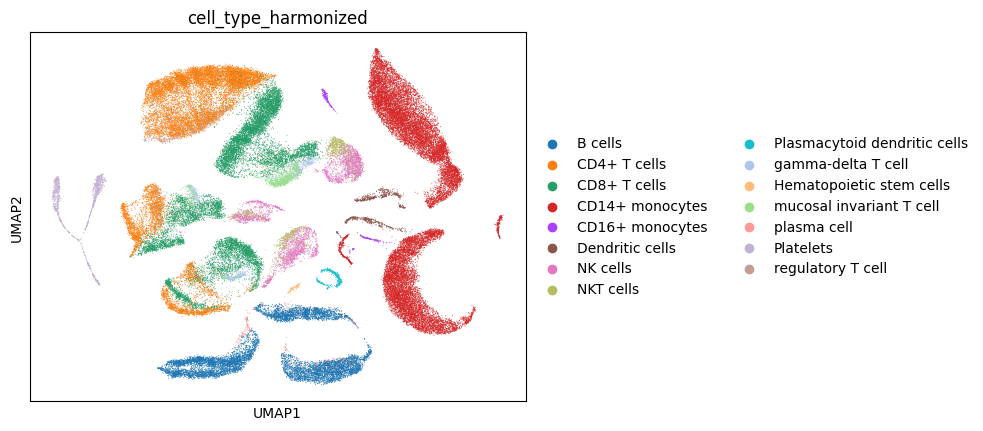

In [6]:
sc.pp.neighbors(adata,use_rep='cls_embeddings') # compute the neighborhood graph
sc.tl.umap(adata) # compute the UMAP coordinates
sc.pl.umap(adata,color='cell_type_harmonized') # plot the UMAP with cell type coloring

Load the LPS paired AnnData for (1) Ensembl→symbol mapping and (2) optional expression-space UMAP / program violin plots.


In [15]:
adata_full = sc.read(FULL_H5AD)
print(adata_full)
print("var columns:", list(adata_full.var.columns))
print("n_expression_cells (all LPS times, no split):", adata_full.n_obs)


AnnData object with n_obs × n_vars = 223478 × 1856
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

We normalize and log-transform the original AnnData object to generate a baseline UMAP visualization. This optional step serves primarily as a comparison to the UMAP derived from PerturbGen cell embeddings.

In [16]:
sc.pp.normalize_total(adata_full) # normalize the data
sc.pp.log1p(adata_full) # log-transform the data

In [17]:
sc.pp.pca(adata_full)
sc.pp.neighbors(adata_full, use_rep="X_pca")
sc.tl.umap(adata_full)

In [18]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata_full.obs['cell_type_harmonized'] = adata_full.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata_full.obs['cell_type_harmonized'].cat.categories}
)


In [19]:
sc.set_figure_params(dpi_save=600) # set high dpi for saved figures

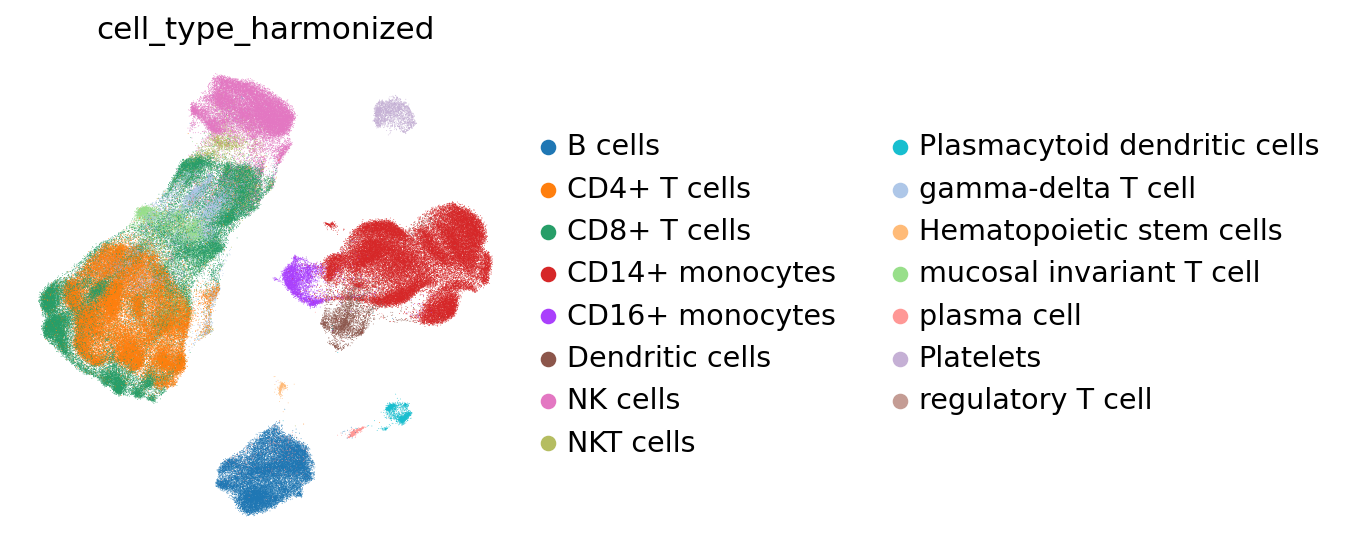

In [20]:

mpl.rcParams.update({ # set global matplotlib parameters
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

sc.pl.umap( # plot UMAP of full data
    adata_full,
    color='cell_type_harmonized',
    frameon=False,
    save='_umapcelltype.png'  
)


In [21]:
adata_full

AnnData object with n_obs × n_vars = 223478 × 1856
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

Map Ensembl IDs in the embedding object to gene symbols via Geneformer's `gene_name_id_dict` (symbol→Ensembl), reversed.


In [22]:
with open(GENE_NAME_ID_DICT, "rb") as f:
    symbol_to_ensembl = pickle.load(f)
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

adata.var["gene_symbol"] = [
    ensembl_to_symbol.get(g, g) for g in adata.var_names.astype(str)
]
n_sym = sum(1 for g, s in zip(adata.var_names, adata.var["gene_symbol"]) if g != s)
print(f"Mapped {n_sym}/{adata.n_vars} Ensembl IDs to gene symbols (embeddings)")

# Same mapping on expression AnnData (used later for score_genes)
if "ensembl_id" in adata_full.var.columns:
    full_ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    full_ids = adata_full.var["gene_ids-0"].astype(str)
else:
    full_ids = pd.Index(adata_full.var_names.astype(str))
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in full_ids]
n_full = sum(
    1 for g, s in zip(full_ids, adata_full.var["gene_symbol"]) if g != s
)
print(f"Mapped {n_full}/{adata_full.n_vars} Ensembl IDs to gene symbols (adata_full)")
adata.var[["gene_symbol"]].head()


Mapped 1855/1856 Ensembl IDs to gene symbols (embeddings)
Mapped 1855/1856 Ensembl IDs to gene symbols (adata_full)


,gene_symbol
ENSG00000188290,HES4
ENSG00000187608,ISG15
ENSG00000186891,TNFRSF18
ENSG00000186827,TNFRSF4
ENSG00000189409,MMP23B


We construct a new AnnData object in which each gene is treated as an observation (analogous to a cell), and its features correspond to a n(here =768)-dimensional learned embedding vector rather than expression values. This representation enables standard single-cell analysis workflows, such as UMAP visualization and clustering, to be directly applied to gene embeddings.

In [23]:
gene_symbols = adata.var['gene_symbol'].values
timepoints = list(adata.varm.keys())

all_embeddings = []
obs_names = []
obs_timepoints = []
obs_genes = []

for tp in timepoints:
    embedding = adata.varm[tp]  
    all_embeddings.append(embedding)
    
    obs_names.extend([f"{g}_{tp}" for g in gene_symbols])
    obs_genes.extend(gene_symbols)
    obs_timepoints.extend([tp] * len(gene_symbols))

X = np.vstack(all_embeddings)

obs = pd.DataFrame({
    "gene_symbol": obs_genes,
    "timepoint": obs_timepoints
}, index=obs_names)

new_adata = ad.AnnData(X=X, obs=obs)

In [24]:
new_adata.obs

,gene_symbol,timepoint
HES4_10h_LPS,HES4,10h_LPS
ISG15_10h_LPS,ISG15,10h_LPS
TNFRSF18_10h_LPS,TNFRSF18,10h_LPS
TNFRSF4_10h_LPS,TNFRSF4,10h_LPS
MMP23B_10h_LPS,MMP23B,10h_LPS
...,...,...
MPP1_90m_LPS,MPP1,90m_LPS
RPS4Y1_90m_LPS,RPS4Y1,90m_LPS
TMSB4Y_90m_LPS,TMSB4Y,90m_LPS
RPS4Y2_90m_LPS,RPS4Y2,90m_LPS


Identify gene–timepoint vectors whose embedding values are all zero and report how many such cases exist.

In [25]:
zero_mask = (new_adata.X == 0).all(axis=1)

num_all_zero = zero_mask.sum()

print(f"Number of gene-timepoint vectors with all-zero values: {num_all_zero}")


Number of gene-timepoint vectors with all-zero values: 30


In [26]:
new_adata = new_adata[~zero_mask].copy() # Remove all-zero embeddings.

Each point below is **one gene at one LPS time**, not a cell.

The 768-d vector is the **mean** of that gene’s decoder embedding over cells at that time (only cells where the gene appeared in the token sequence). Cell types are pooled: 6h B / T / monocytes all go into the same `6h_LPS` mean. Times are **not** mixed: `IL1B` has three separate means (`90m`, `6h`, `10h`).

So this is not the 69k-cell atlas. After dropping all-zero vectors you have ~5,538 points (≈1,856 genes × 3 times). Color is the true time label from metadata. Default drawing order put `90m` on top and hid `6h`/`10h`; the next cell shuffles and uses tiny points so the three times are visible. Same gene at three times often lands on almost the same pixel — that is expected if gene identity dominates time.

Neighbors + UMAP are computed on this gene×time object; the plot is colored by `timepoint`.

In [27]:
sc.pp.neighbors(new_adata) # compute the neighborhood graph
sc.tl.umap(new_adata) # compute the UMAP coordinates

/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 768 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


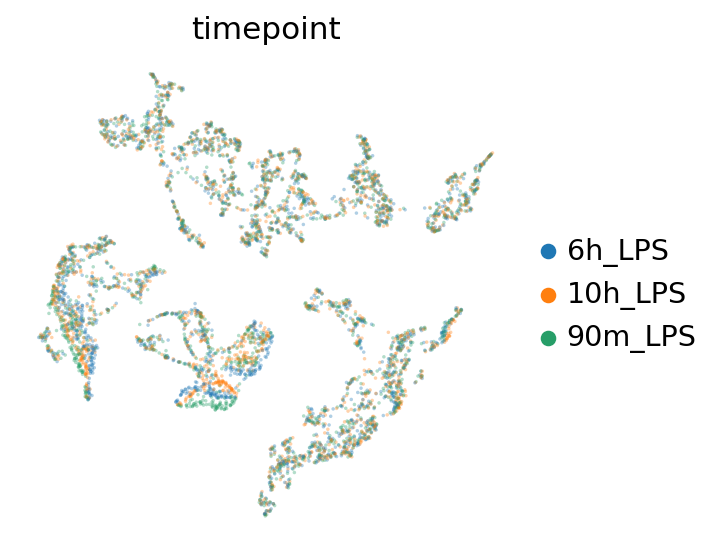

In [28]:
# Tiny points + shuffle: 90m was drawn last and covered 6h/10h.
# Same gene at 3 times sits on almost the same UMAP pixel.
rng = np.random.default_rng(0)
order = rng.permutation(new_adata.n_obs)
sc.pl.umap(
    new_adata[order],
    color="timepoint",
    size=10,
    alpha=0.35,
    frameon=False,
)

Gene programs are identified by applying Leiden clustering to the gene embedding space, with each resulting cluster representing a coherent gene program.

In [29]:
sc.tl.leiden(new_adata,resolution=1,key_added='r1') # cluster gene embeddings

/tmp/ipykernel_2977784/172354348.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(new_adata,resolution=1,key_added='r1') # cluster gene embeddings


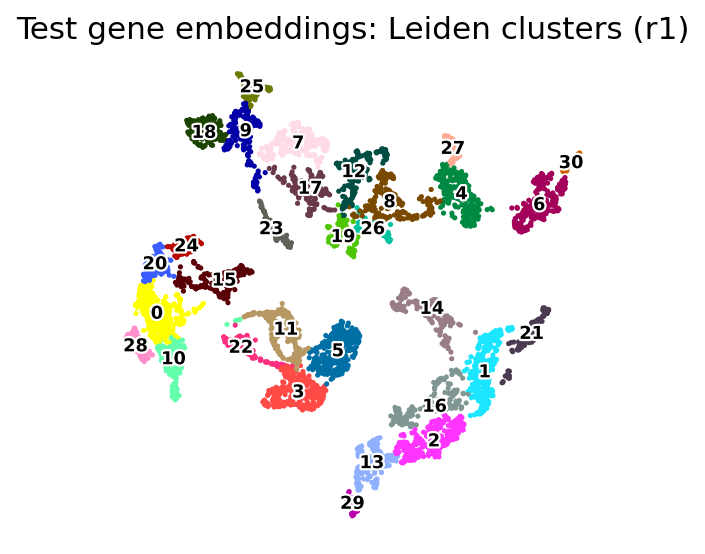

How many points in each cluster:
r1
0     334
1     329
10    208
11    207
12    203
13    201
14    192
15    174
16    169
17    161
18    147
19    139
2     322
20    135
21    129
22    103
23     96
24     87
25     84
26     72
27     72
28     68
29     51
3     294
30     42
4     292
5     289
6     264
7     248
8     218
9     208
Name: count, dtype: int64


In [30]:
# Each color = one Leiden program (r1). Numbers in the legend are cluster ids, not ranks.
sc.pl.umap(
    new_adata,
    color="r1",
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    title="Test gene embeddings: Leiden clusters (r1)",
    frameon=False,
)

print("How many points in each cluster:")
print(new_adata.obs["r1"].astype(str).value_counts().sort_index())


For annotating gene programs, we recommend using predefined gene sets as guidance.

Enrichr is called **once per Leiden cluster**. Hitting the web API with library *names* on every cluster is slow (31 clusters × HTTP, 10+ min, often looks frozen). The next cell downloads `GO_Biological_Process_2025` and `Reactome_Pathways_2024` **once**, caches them under `RESULTS_DIR`, then scores clusters **locally**. Gene lists are unique symbols (same gene at 90m/6h/10h is not sent three times). `no_plot=True`. Re-run is fast after the first download.

In [31]:
import pickle

# Download each Enrichr library once, then score clusters locally.
# Passing library names to gp.enrichr() hits maayanlab on every cluster.
LIB_NAMES = ["GO_Biological_Process_2025", "Reactome_Pathways_2024"]
LIB_CACHE = RESULTS_DIR / "enrichr_libraries.pkl"

if LIB_CACHE.is_file():
    gene_set_dicts = pickle.loads(LIB_CACHE.read_bytes())
    print("Loaded cached Enrichr libraries:", list(gene_set_dicts))
else:
    gene_set_dicts = {}
    for name in LIB_NAMES:
        print("Downloading", name, "...")
        gene_set_dicts[name] = gp.get_library(name, organism="Human", min_size=5, max_size=5000)
        print(" ", name, len(gene_set_dicts[name]), "terms")
    LIB_CACHE.write_bytes(pickle.dumps(gene_set_dicts))
    print("Wrote", LIB_CACHE)

clusters = sorted(
    new_adata.obs["r1"].unique(),
    key=lambda x: int(str(x)) if str(x).isdigit() else str(x),
)
results = {}
for i, cluster in enumerate(clusters, 1):
    cluster_genes = list(
        dict.fromkeys(
            new_adata.obs.loc[new_adata.obs["r1"] == cluster, "gene_symbol"].astype(str)
        )
    )
    print(f"[{i}/{len(clusters)}] cluster {cluster}: {len(cluster_genes)} unique genes")
    try:
        enr = gp.enrichr(
            gene_list=cluster_genes,
            gene_sets=list(gene_set_dicts.values()),
            organism="Human",
            outdir=None,
            cutoff=0.5,
            no_plot=True,
        )
        top = enr.results.sort_values("Adjusted P-value").head(5)
        results[cluster] = top
        if len(top):
            print("   top:", str(top.iloc[0]["Term"])[:90])
    except Exception as e:
        print("   SKIP:", type(e).__name__, e)
        results[cluster] = pd.DataFrame()

n_ok = sum(len(v) > 0 for v in results.values())
print(f"done: {n_ok}/{len(results)} clusters with Enrichr terms")

Loaded cached Enrichr libraries: ['GO_Biological_Process_2025', 'Reactome_Pathways_2024']
[1/31] cluster 0: 117 unique genes
   top: Polo-like Kinase Mediated Events
[2/31] cluster 1: 110 unique genes
   top: Hemostasis
[3/31] cluster 2: 108 unique genes
   top: Synthesis of Bile Acids and Bile Salts via 27-Hydroxycholesterol
[4/31] cluster 3: 98 unique genes
   top: Regulation of Chromosome Segregation (GO:0051983)
[5/31] cluster 4: 98 unique genes
   top: Immune System
[6/31] cluster 5: 106 unique genes
   top: peptidyl-L-cysteine S-palmitoylation (GO:0018230)
[7/31] cluster 6: 88 unique genes
   top: Immune System
[8/31] cluster 7: 84 unique genes
   top: Immune System
[9/31] cluster 8: 79 unique genes
   top: Carbon Dioxide Transport (GO:0015670)
[10/31] cluster 9: 70 unique genes
   top: Apical Junction Assembly (GO:0043297)
[11/31] cluster 10: 72 unique genes
   top: ATP Transport (GO:0015867)
[12/31] cluster 11: 72 unique genes
   top: Axonemal Central Apparatus Assembly (GO:190

As an example, we annotate cluster **19** as cytokine signaling: in this 90/10 extract that box is Enrichr “Immune System”, and CXCL8 (90m) / IL32 / IL7R land there. Leiden IDs are from this extract; they will not match the 16 Aug paper atlas (that tutorial used cluster 6). You can also calculate the z-score expression of any gene program of interest within the cell space.


In [32]:
# Force adata_full.var_names -> gene symbols (match new_adata.obs['gene_symbol']).
# NOTE: this h5ad's gene_name column is still Ensembl IDs — always map via Geneformer dict.
if "ensembl_to_symbol" not in globals():
    with open(GENE_NAME_ID_DICT, "rb") as f:
        symbol_to_ensembl = pickle.load(f)
    ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

if "ensembl_id" in adata_full.var.columns:
    ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    ids = adata_full.var["gene_ids-0"].astype(str)
else:
    ids = pd.Index(adata_full.var_names.astype(str))

adata_full.var["ensembl_id"] = ids.values
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in ids]
adata_full.var_names = adata_full.var["gene_symbol"].astype(str).values
adata_full.var_names_make_unique()

n_mapped = int((~pd.Index(adata_full.var_names).str.startswith("ENSG")).sum())
print("adata_full var_names (symbols):", list(adata_full.var_names[:5]))
print(f"Non-Ensembl var_names: {n_mapped}/{adata_full.n_vars}")
assert n_mapped > 0, "Symbol mapping failed — check GENE_NAME_ID_DICT / ensembl_to_symbol"


adata_full var_names (symbols): ['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MMP23B']
Non-Ensembl var_names: 1855/1856


In [33]:
# Why cluster 19? Why IL1B / CXCL8 / ... ?
# Run this AFTER: new_adata, leiden (r1), and Enrichr (results = {}).

PROGRAM_CLUSTER = "19"

print("=" * 60)
print("1) WHO CHOSE", PROGRAM_CLUSTER, "?")
print("   Typed in cluster_map. Leiden did not pick a name.")
print("   Immune System Enrichr; CXCL8_90m / IL32 / IL7R sit in box 19 in this extract.")
print("=" * 60)

r1 = new_adata.obs["r1"].astype(str)
example_id = PROGRAM_CLUSTER
if example_id not in set(r1):
    example_id = sorted(set(r1), key=lambda x: int(x) if str(x).isdigit() else x)[0]
    print("Cluster", PROGRAM_CLUSTER, "is missing in this run. Using", example_id, "instead.")

print("\nGenes sitting in box", example_id, "(first 15 unique):")
print(list(new_adata.obs.loc[r1 == example_id, "gene_symbol"].unique()[:15]))

key = next(k for k in results if str(k) == example_id)
print("\nEnrichr for box", example_id, "(this is the evidence for naming it):")
display(results[key].head(5))

print("\nOther boxes whose Enrichr text mentions cytokine/chemokine/interleukin:")
for cluster, df in results.items():
    if "Term" not in getattr(df, "columns", []):
        continue
    blob = " ".join(df["Term"].astype(str).str.lower())
    if any(w in blob for w in ["cytokine", "chemokine", "interleukin"]):
        top = str(df.iloc[0]["Term"]) if len(df) else ""
        mark = "  <-- tutorial uses this" if str(cluster) == str(PROGRAM_CLUSTER) else ""
        print(f"  cluster {cluster}: {top}{mark}")

print("\n" + "=" * 60)
print("2) WHO CHOSE IL1B, CXCL8, ...?")
print("   Not Enrichr and not Leiden. The paper/tutorial highlight list")
print("   of famous LPS cytokine genes, to DRAW on the UMAP.")
print("=" * 60)

highlight_genes = ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R", "CXCL8", "CXCL3", "CXCL9"]
sub = new_adata.obs[new_adata.obs["gene_symbol"].str.upper().isin(highlight_genes)].copy()
sub["r1"] = sub["r1"].astype(str)
print("\nWhere those highlight genes actually landed (gene x time -> r1):")
display(sub[["gene_symbol", "timepoint", "r1"]].sort_values(["gene_symbol", "timepoint"]))
print("Count of highlight points per cluster:")
print(sub["r1"].value_counts())
in_box = sub.loc[sub["r1"] == str(example_id), "gene_symbol"].str.upper().unique().tolist()
print(f"\nHighlight genes that ARE in box {example_id}:", in_box)
print(f"Highlight genes that are NOT in box {example_id}:", sorted(set(highlight_genes) - set(in_box)))


1) WHO CHOSE 21 ?
   Typed in cluster_map. Leiden did not pick a name.
   90m copies of IL1B/CXCL8/CXCL3/IL1RN/PTX3 sit in box 21 in this extract.

Genes sitting in box 21 (first 15 unique):
['UBXN11', 'ZCCHC17', 'TSPAN2', 'SMC6', 'TMBIM1', 'CMC1', 'PHLDB2', 'CCDC50', 'TACC3', 'CASP3', 'DAP', 'DBN1', 'CDYL', 'E2F3', 'PRKAR1B']

Enrichr for box 21 (this is the evidence for naming it):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
68,gs_ind_0,Negative Regulation of Cell-Substrate Junction...,2/14,0.000439,0.063192,92.885714,718.136338,CORO1C;PHLDB2
76,gs_ind_0,Negative Regulation of Focal Adhesion Assembly...,2/14,0.000439,0.063192,92.885714,718.136338,CORO1C;PHLDB2
62,gs_ind_0,Negative Regulation of Cell Junction Assembly ...,2/23,0.001205,0.115651,53.970100,362.761517,CORO1C;PHLDB2
66,gs_ind_0,Negative Regulation of Cell-Matrix Adhesion (G...,2/30,0.002051,0.118140,40.694793,251.876682,CORO1C;PHLDB2
92,gs_ind_0,Negative Regulation of Protein Localization to...,2/29,0.001917,0.118140,42.177489,263.904393,TMBIM1;GDI1



Other boxes whose Enrichr text mentions cytokine/chemokine/interleukin:
  cluster 6: Immune System
  cluster 7: Immune System
  cluster 8: Carbon Dioxide Transport (GO:0015670)
  cluster 12: Immune System
  cluster 18: Immune System
  cluster 30: Keratinocyte Proliferation (GO:0043616)

2) WHO CHOSE IL1B, CXCL8, ...?
   Not Enrichr and not Leiden. The paper/tutorial highlight list
   of famous LPS cytokine genes, to DRAW on the UMAP.

Where those highlight genes actually landed (gene x time -> r1):


,gene_symbol,timepoint,r1
CXCL3_6h_LPS,CXCL3,6h_LPS,17
CXCL3_10h_LPS,CXCL3,10h_LPS,17
CXCL3_90m_LPS,CXCL3,90m_LPS,17
CXCL8_6h_LPS,CXCL8,6h_LPS,12
CXCL8_10h_LPS,CXCL8,10h_LPS,12
CXCL8_90m_LPS,CXCL8,90m_LPS,19
CXCL9_6h_LPS,CXCL9,6h_LPS,8
CXCL9_10h_LPS,CXCL9,10h_LPS,8
CXCL9_90m_LPS,CXCL9,90m_LPS,8
IL1B_6h_LPS,IL1B,6h_LPS,4


Count of highlight points per cluster:
r1
19    7
7     3
4     3
2     3
17    3
8     3
12    2
Name: count, dtype: int64

Highlight genes that ARE in box 21: []
Highlight genes that are NOT in box 21: ['CXCL3', 'CXCL8', 'CXCL9', 'IL1B', 'IL1RN', 'IL32', 'IL7R', 'PTX3']


In [34]:
# Score cluster 19 on expression space (var_names must be symbols — run cell above first)
if "PROGRAM_CLUSTER" not in globals():
    PROGRAM_CLUSTER = "19"

genes_cluster = list(
    dict.fromkeys(new_adata[new_adata.obs["r1"].astype(str) == str(PROGRAM_CLUSTER)].obs["gene_symbol"])
)
genes_present = [g for g in genes_cluster if g in adata_full.var_names]

# Fallback: if var_names are still Ensembl, resolve symbols -> Ensembl
if not genes_present:
    if "symbol_to_ensembl" not in globals():
        with open(GENE_NAME_ID_DICT, "rb") as f:
            symbol_to_ensembl = pickle.load(f)
    genes_present = [
        symbol_to_ensembl[g]
        for g in genes_cluster
        if g in symbol_to_ensembl and symbol_to_ensembl[g] in adata_full.var_names
    ]

print(f"Cluster {PROGRAM_CLUSTER} genes in adata_full: {len(genes_present)}/{len(genes_cluster)}")
print("example cluster genes:", genes_cluster[:5])
print("example adata_full genes:", list(adata_full.var_names[:5]))
assert genes_present, (
    "No cluster genes found in adata_full — re-run the symbol-alignment cell above."
)

sc.tl.score_genes(
    adata_full, gene_list=genes_present, score_name="Cytokine Signaling"
)


Cluster 21 genes in adata_full: 43/43
example cluster genes: ['UBXN11', 'ZCCHC17', 'TSPAN2', 'SMC6', 'TMBIM1']
example adata_full genes: ['HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'MMP23B']


In [36]:
if "PROGRAM_CLUSTER" not in globals():
    PROGRAM_CLUSTER = "19"

cluster_map = {
    str(PROGRAM_CLUSTER): "Cytokine Signaling",
}

new_adata.obs["MoA"] = new_adata.obs["r1"].astype(str).map(cluster_map).fillna("Others")
print("Cytokine Signaling <- Leiden", PROGRAM_CLUSTER)
print(new_adata.obs["MoA"].value_counts())


Cytokine Signaling <- Leiden 21
MoA
Others                5409
Cytokine Signaling     129
Name: count, dtype: int64


Visualize the UMAP and highlight the cluster containing the genes of interest.

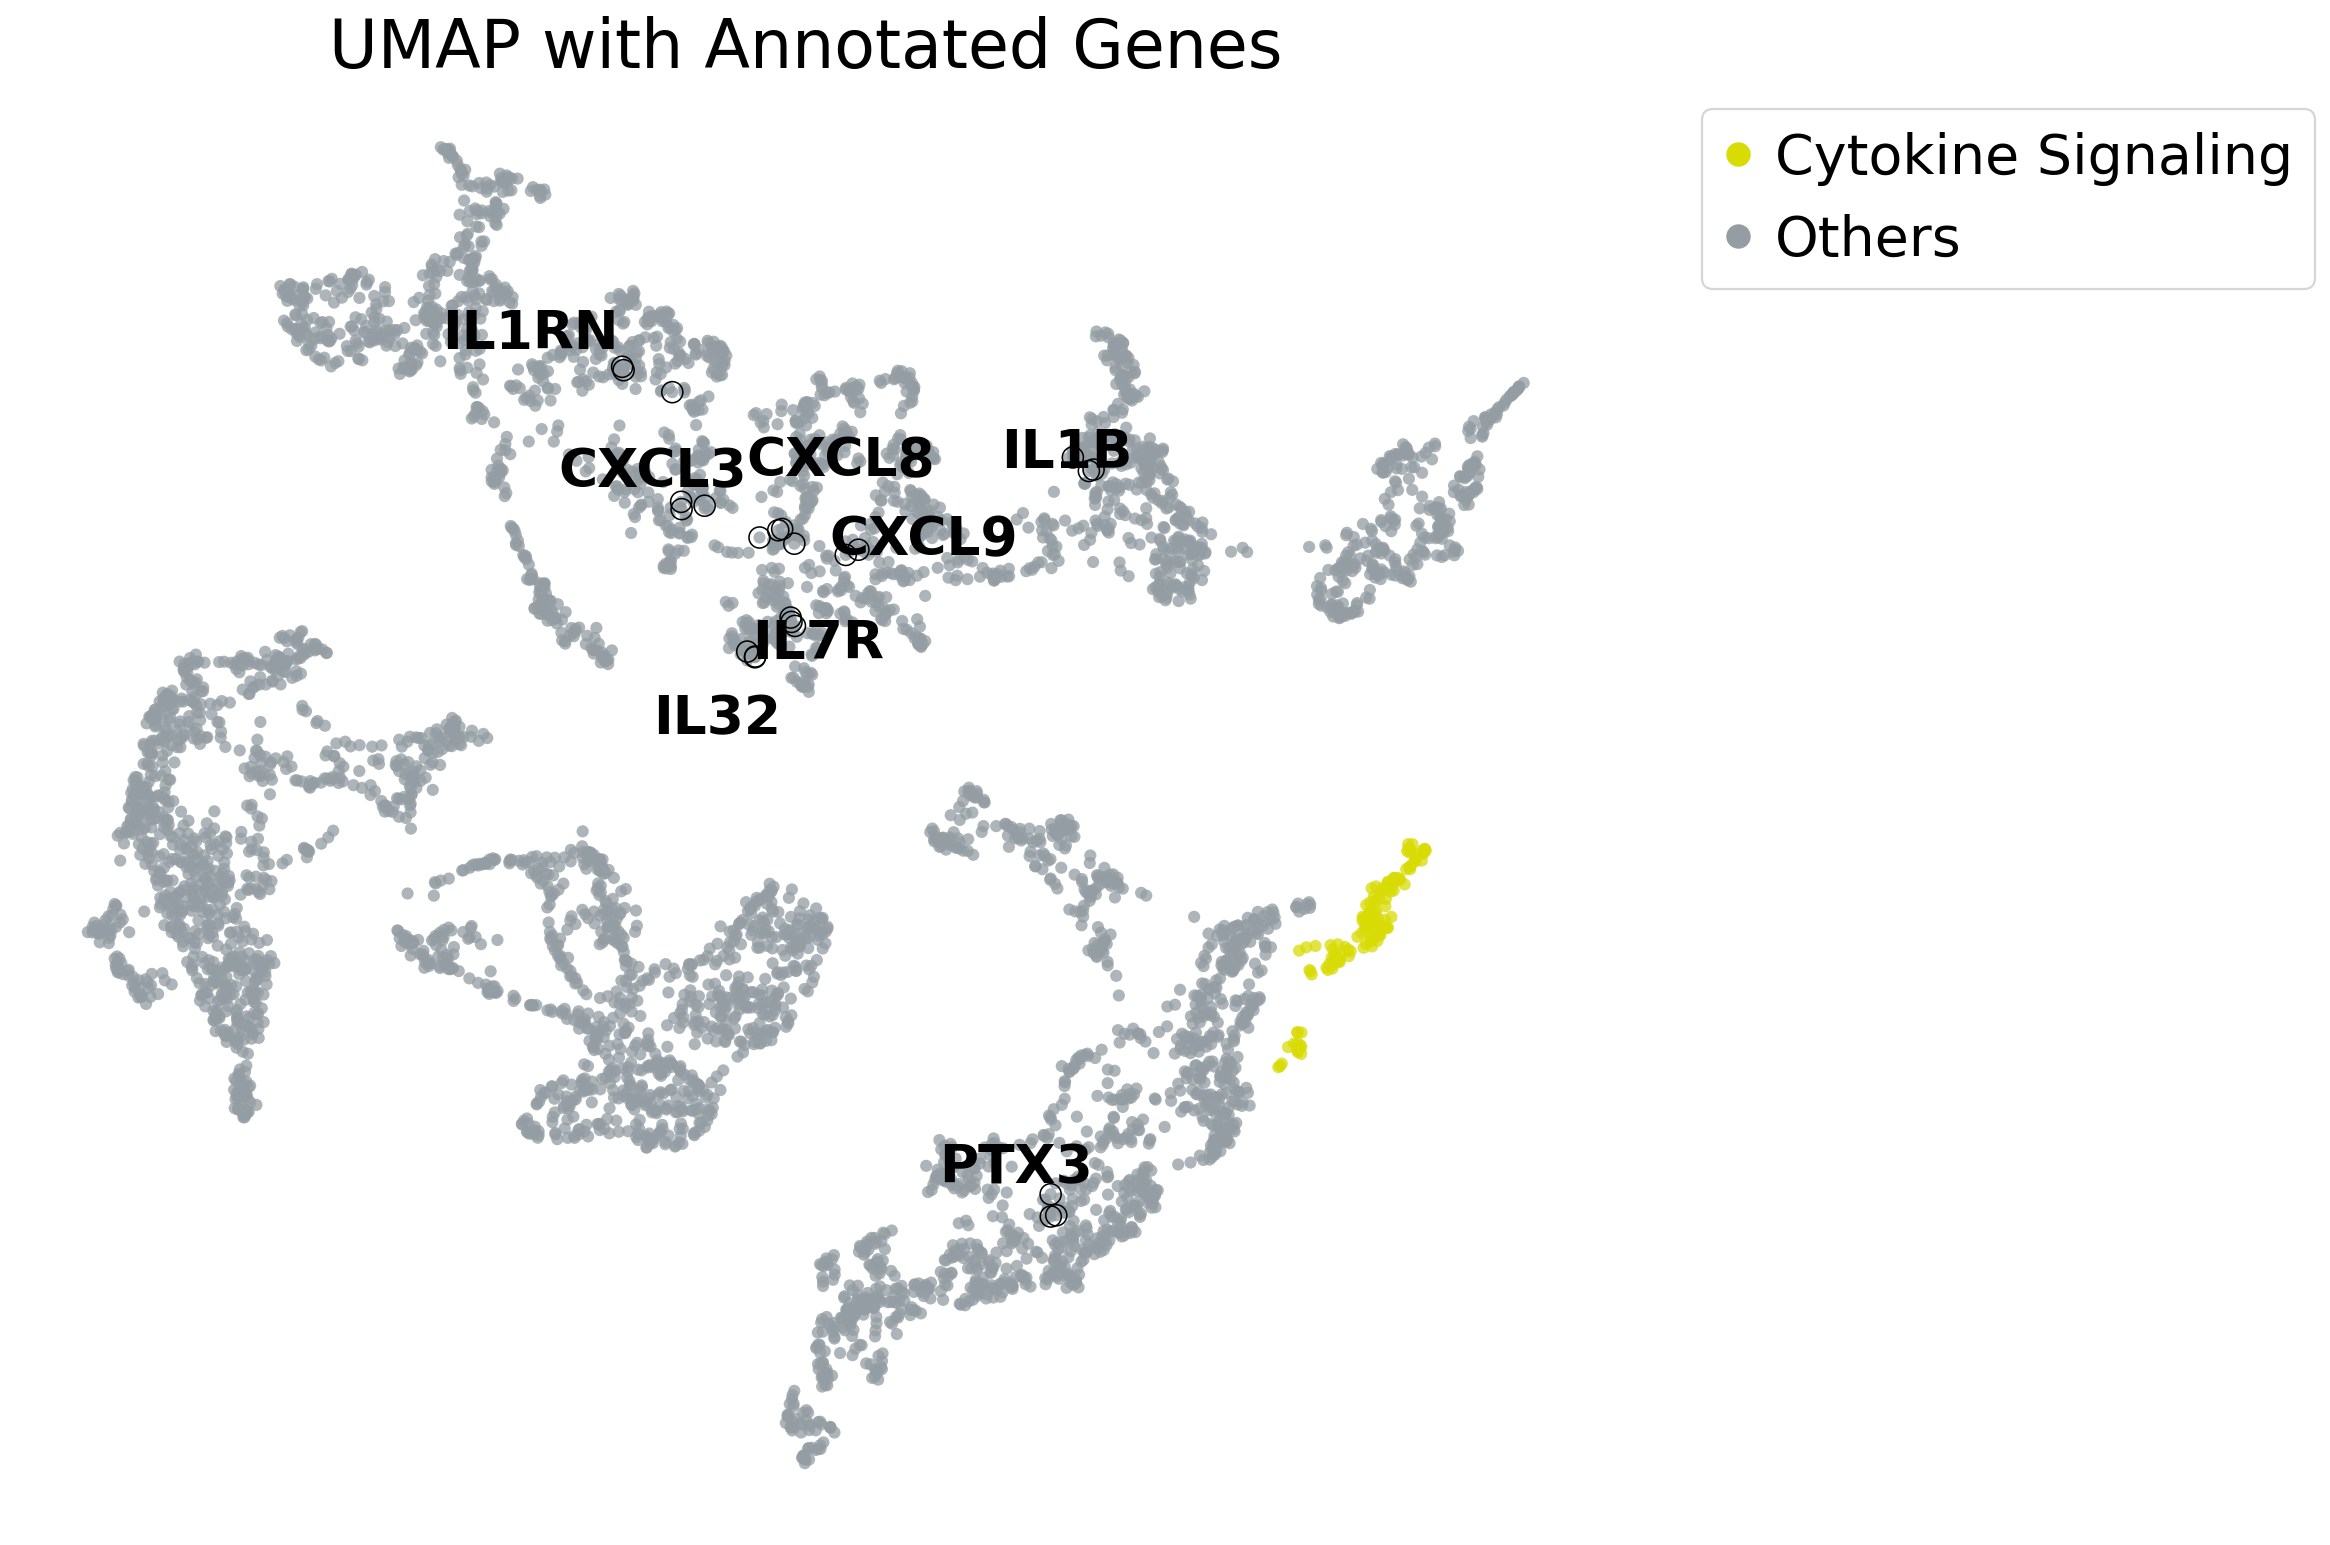

In [37]:
highlight_dict = {
    'Cytokine Signaling': ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R","CXCL8","CXCL3","CXCL9"],
}
custom_colors = {
    'Cytokine Signaling': '#d9db05',
    'Others': '#939da3',
}


umap_df = pd.DataFrame(new_adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_df['MoA']  = new_adata.obs['MoA'].astype(str).values          
umap_df['gene'] = new_adata.obs['gene_symbol'].astype(str).values  

present = sorted(umap_df['MoA'].unique())
palette = {k: custom_colors.get(k, '#939da3') for k in present}

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='MoA',
    palette=palette, linewidth=0, alpha=0.75, s=30
)
plt.title('UMAP with Annotated Genes', fontsize=30)
plt.xlabel('UMAP1', fontsize=24); plt.ylabel('UMAP2', fontsize=24)
plt.axis('off'); plt.grid(False)

texts = []
for moa, genes in highlight_dict.items():
    for gene in genes:
        mask = (umap_df['gene'].str.upper() == gene.upper()) & (umap_df['MoA'] == moa)
        if not mask.any():
            mask = (umap_df['gene'].str.upper() == gene.upper())

        if mask.any():
            plt.scatter(
                umap_df.loc[mask, 'UMAP1'],
                umap_df.loc[mask, 'UMAP2'],
                s=90, linewidths=0.7, edgecolors='k', facecolors='none', zorder=5
            )

            x_med = umap_df.loc[mask, 'UMAP1'].median()
            y_med = umap_df.loc[mask, 'UMAP2'].median()
            jitter_x = x_med - 1.0 if gene == "IL1RN" else x_med + np.random.uniform(-0.5, 0.5)
            jitter_y = y_med + np.random.uniform(-0.5, 0.5)

            texts.append(
                plt.text(jitter_x, jitter_y, gene,
                         fontsize=24, fontweight='bold', ha='center', va='center', zorder=6)
            )

adjust_text(
    texts,
    expand_points=(15, 15),
    expand_text=(10, 10),
    force_points=5.0,
    force_text=5.0,
    pad=10.0,
    only_move={'points': 'xy', 'text': 'xy'},
    autoalign='xy',
    lim=1500
)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=palette[k], markersize=12) for k in present]
plt.legend(handles=handles, labels=present, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=25)

plt.tight_layout()
plt.savefig(FIG_DIR / "umap_highlight_gene_symbol.png", dpi=600, bbox_inches="tight")
plt.show()


Optionally, you may visualize the z-score expression of a gene program of interest, stratified by cell type or another relevant variable.

/tmp/ipykernel_2977784/2005851278.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cell_type_harmonized')['Cytokine Signaling']
/tmp/ipykernel_2977784/2005851278.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


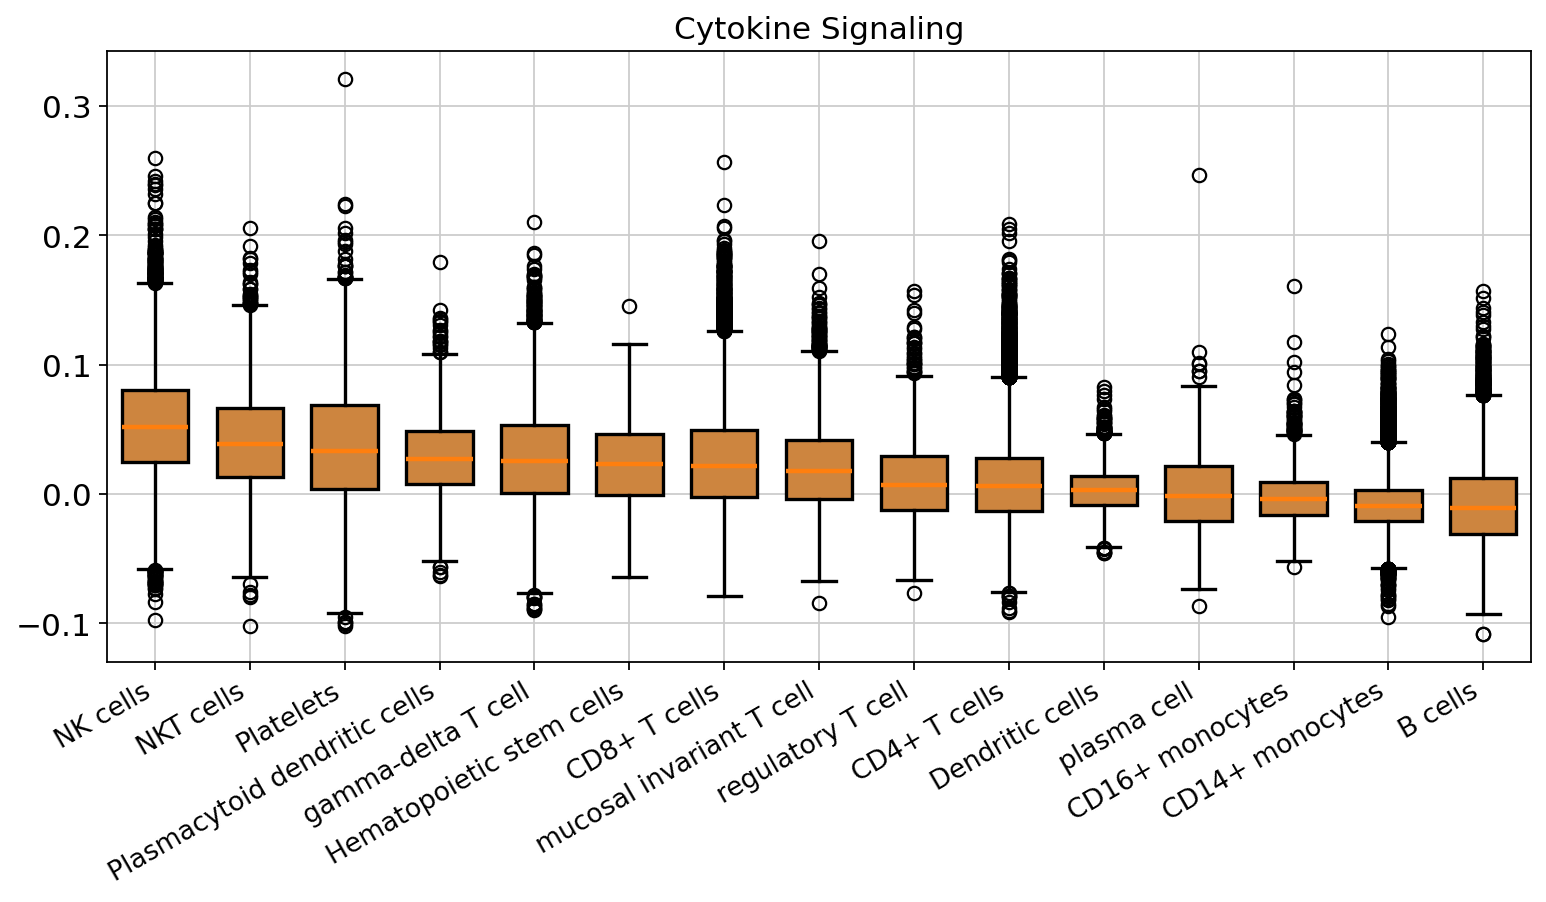

In [38]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})


df = adata_full.obs[['cell_type_harmonized', 'Cytokine Signaling']].dropna()

ordered_cell_types = (
    df.groupby('cell_type_harmonized')['Cytokine Signaling']
      .median()
      .sort_values(ascending=False)
      .index.tolist()
)

data = [df.loc[df['cell_type_harmonized'] == ct, 'Cytokine Signaling'].values
        for ct in ordered_cell_types]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    data,
    patch_artist=True,  
    labels=ordered_cell_types,
    widths=0.7,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5)
)

for box in bp['boxes']:
    box.set_facecolor('peru')

ax.set_title('Cytokine Signaling')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "cytokine_signaling_boxplot.pdf", dpi=600, bbox_inches="tight", format="pdf")
plt.show()


We subset the data to the myeloid lineage, as the gene program was highly enriched in these cells. We then examined the gene program scores within the myeloid population across different timepoints.

In [39]:
myeloids = adata_full[adata_full.obs['cell_type_harmonized'].isin(['CD14+ monocytes','CD16+ monocytes','Dendritic cells'])].copy()

In [40]:
s = myeloids.obs['time_after_LPS'].astype('category')

rename_map = {
    '90m_LPS': '90m',
    '6h_LPS':  '6h',
    '10h_LPS': '10h',
    'normal':  'normal',
}
s = s.cat.rename_categories({k: v for k, v in rename_map.items() if k in s.cat.categories})

new_order = ['normal', '90m', '6h', '10h']
s = s.cat.reorder_categories(new_order, ordered=True)

myeloids.obs['time_after_LPS'] = s

palette = {
    'normal': '#d62728',
    '90m':    '#2ca02c',
    '6h':     '#1f77b4',
    '10h':    '#ff7f0e',
}
myeloids.uns['time_after_LPS_colors'] = [palette[c] for c in s.cat.categories]

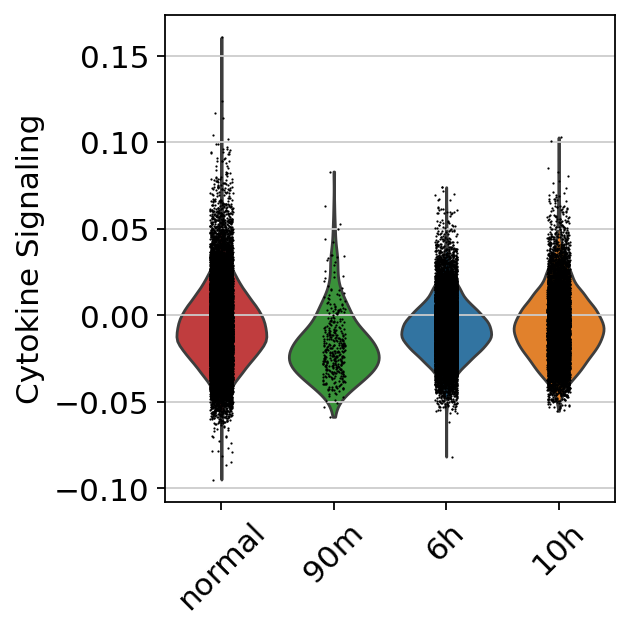

In [41]:
sc.pl.violin(myeloids,keys='Cytokine Signaling',groupby='time_after_LPS',rotation=45,save='myeloids.png') # plot violin plot of Cytokine Signaling score in myeloid cells